# Valuation Engine Prototype

This notebook serves as the experimental environment for the `ValuationEngine`. It demonstrates how to train and evaluate the hybrid model using both financial metrics and NLP embeddings.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_log_error, make_scorer

# Enable autoreload
%load_ext autoreload
%autoreload 2

# Add src to path
sys.path.append(os.path.abspath("../src"))
from valuation import ValuationEngine

%matplotlib inline
sns.set_theme(style="whitegrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Data Loading
We load the dataset processed by the `FeatureProcessor` (Gold Layer). The engine expects flattened NLP columns (`nlp_0`, `nlp_1`, etc.).

In [11]:
data_path = "../data/processed/PUBLIC_embedded.parquet"

if os.path.exists(data_path):
    df = pd.read_parquet(data_path)
    print(f"Loaded {len(df)} companies with {len(df.columns)} columns.")
    
    # 1. Filter for positive valuations (CRITICAL for log-transform)
    df = df[df['enterprise_value'] > 0]
    print(f"Filtered for positive valuations: {len(df)} companies remaining.")
    
    # 2. Diagnostic Check
    print(f"Diagnostic - Minimum Enterprise Value: {df['enterprise_value'].min():,.2f}")
    display(df.head())
else:
    print(f"Data not found at {data_path}. Creating dummy data for demonstration.")
    # Creating dummy data with flattened NLP features
    n_samples = 100
    df = pd.DataFrame({
        "forwardPE": np.random.uniform(10, 40, n_samples),
        "ev_to_ebitda": np.random.uniform(5, 20, n_samples),
        "ebitda": np.random.uniform(100, 1000, n_samples),
        "total_cash": np.random.uniform(50, 200, n_samples),
        "total_debt": np.random.uniform(10, 100, n_samples),
        "enterprise_value": np.random.uniform(500, 5000, n_samples)
    })
    # Add 384 NLP features
    nlp_data = np.random.rand(n_samples, 384)
    nlp_df = pd.DataFrame(nlp_data, columns=[f"nlp_{i}" for i in range(384)])
    df = pd.concat([df, nlp_df], axis=1)
    display(df.head())


# Very Very large enterprise values result in inaccurate metrics
#df = df[df['enterprise_value'] < 5e12]

Loaded 8050 companies with 393 columns.
Filtered for positive valuations: 7593 companies remaining.
Diagnostic - Minimum Enterprise Value: 60,814.00


,enterprise_value,forwardPE,ev_to_ebitda,ebitda,total_cash,total_debt,estimated_revenue,employee_count,sector,nlp_0,...,nlp_374,nlp_375,nlp_376,nlp_377,nlp_378,nlp_379,nlp_380,nlp_381,nlp_382,nlp_383
0,5.170628e+12,17.027882,31.240,165514002432,5.317200e+10,1.281400e+10,2.534910e+11,42000.0,Technology,-0.059150,...,-0.035018,-0.028591,0.014662,-0.092712,0.029643,0.026535,-0.013199,-0.065995,0.014612,0.018574
1,4.609101e+12,26.421965,28.572,161315995648,1.268400e+11,9.587600e+10,4.224980e+11,194668.0,Communication Services,-0.059735,...,0.011315,-0.044257,-0.024711,-0.135265,0.032019,0.070319,-0.015535,-0.074552,0.032307,-0.036426
2,4.551953e+12,32.155922,28.454,159975997440,6.850700e+10,8.471100e+10,4.514420e+11,166000.0,Technology,-0.042323,...,-0.040436,0.024960,0.037074,-0.097955,0.022558,0.120378,0.046419,-0.064816,0.104943,0.013485
3,3.156524e+12,21.645250,17.113,184457003008,7.822800e+10,1.254320e+11,3.182730e+11,228000.0,Technology,-0.014270,...,0.022693,0.035224,0.073339,-0.102653,0.079596,0.118757,-0.010114,-0.027585,0.031214,-0.044478
4,2.957284e+12,27.011812,18.974,155860992000,1.430890e+11,2.355400e+11,7.427760e+11,1575000.0,Consumer Cyclical,0.039800,...,0.040109,-0.000710,0.027882,-0.100945,0.072389,0.122982,-0.006967,-0.052227,0.004188,0.016085


## 2. Model Training & Evaluation
We initialize the engine in `public` mode and prepare the data for the default target: `enterprise_value`.

In [13]:
# Initialize engine in public mode
engine = ValuationEngine(mode="private", n_estimators=100)

# Prepare features (X) and target (y)
X, y = engine.prepare_data(df, target_col="forwardPE")

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} samples with {X_train.shape[1]} features.")

# Define a small parameter grid for demonstration

"""
param_grid = {
    "preprocess__nlp_prep__n_components": [30],
    "preprocess__fin_prep__imputer__n_neighbors": [3],
    "model__regressor__estimator__max_depth": [5],
    "model__regressor__estimator__learning_rate": [0.1],
    "model__regressor__estimator__n_estimators": [500]
}
"""

param_grid = {
    "preprocess__nlp_prep__pca__n_components": [10, 30, 50],
    "preprocess__fin_prep__imputer__n_neighbors": [3, 5, 10],
    "model__regressor__estimator__max_depth": [3, 5],
    "model__regressor__estimator__learning_rate": [0.1],
    "model__regressor__estimator__n_estimators": [300, 500, 800],
    "model__regressor__estimator__subsample": [0.6, 0.8, 1.0],
    "model__regressor__estimator__colsample_bytree": [0.6, .8, 1.0]
}


# 30, 3, 5, .1, 500 - > .28

# Tune hyperparameters (This replaces engine.train())
best_params = engine.tune_hyperparameters(X_train, y_train, param_distributions=None, n_iter=10, cv=100, scoring = "neg_mean_squared_log_error")
print(f"\nBest Parameters Found: {best_params}")

# Evaluate performance using the tuned pipeline
metrics = engine.evaluate(X_test, y_test)

print("\nPerformance Metrics:")
for k, v in metrics.items():
    print(f"{k.upper()}: {v:.4f}")

Dropping 3164 rows with NaN targets.


Training on 3543 samples with 387 features.


Tuning Hyperparameters:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting 100 folds for each of 10 candidates, totalling 1000 fits


/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/rya


Best Parameters Found: {'model__regressor__estimator__colsample_bytree': np.float64(0.9914704912223224), 'model__regressor__estimator__learning_rate': np.float64(0.014329409164607492), 'model__regressor__estimator__max_depth': 7, 'model__regressor__estimator__n_estimators': 918, 'model__regressor__estimator__subsample': np.float64(0.8493303181577982), 'preprocess__fin_prep__imputer__n_neighbors': 11, 'preprocess__nlp_prep__pca__n_components': 48}

Performance Metrics:
R2: -0.0135
MAE: 15.2877
MAPE: 1.1235
MDAPE: 0.4268
ACCURACY_20: 0.2483
RMSLE: 1.1054


## 3. Visualization
Visualize the Predicted vs Actual Enterprise Values.

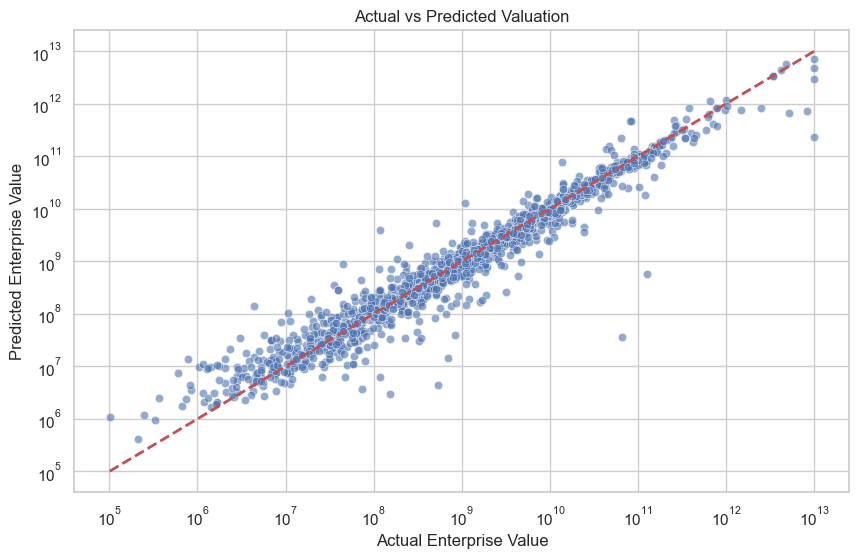

In [5]:
y_pred_df = engine.predict(X_test)
y_pred = y_pred_df["enterprise_value"]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test["enterprise_value"], y=y_pred, alpha=0.6)
plt.plot([y_test.min().min(), y_test.max().max()], [y_test.min().min(), y_test.max().max()], 'r--', lw=2)
plt.xlabel("Actual Enterprise Value")
plt.ylabel("Predicted Enterprise Value")
plt.title("Actual vs Predicted Valuation")
plt.xscale('log')
plt.yscale('log')
plt.show()


## 4. Hybrid Model Usage
The `hybrid` mode combines both public financial multiples (PE, EV/EBITDA) and private-style proxies (Employee Count, Revenue). This is the most comprehensive modeling mode available in the `ValuationEngine`.

In [ ]:
# Initialize engine in hybrid mode
hybrid_engine = ValuationEngine(mode="hybrid", n_estimators=100)

# Prepare data (X will now contain 7 financial columns + NLP + categorical)
X_hybrid, y_hybrid = hybrid_engine.prepare_data(df, target_col="enterprise_value")

# Split into training and test sets
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_hybrid, y_hybrid, test_size=0.2, random_state=42)

print(f"Hybrid Mode: Training on {X_train_h.shape[0]} samples with {X_train_h.shape[1]} features.")

# Hyperparameter tuning with the hybrid feature set
hybrid_param_grid = {
    "preprocess__nlp_prep__pca__n_components": [30],
    "preprocess__fin_prep__imputer__n_neighbors": [5],
    "model__regressor__estimator__max_depth": [5],
    "model__regressor__estimator__learning_rate": [0.05],
    "model__regressor__estimator__n_estimators": [500]
}

best_params_h = hybrid_engine.tune_hyperparameters(
    X_train_h, 
    y_train_h, 
    param_distributions=hybrid_param_grid, 
    n_iter=1, 
    cv=3, 
    scoring="neg_mean_squared_log_error"
)

print(f"\nHybrid Best Params: {best_params_h}")

# Evaluate the hybrid model
hybrid_metrics = hybrid_engine.evaluate(X_test_h, y_test_h)

print("\nHybrid Performance Metrics:")
for k, v in hybrid_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

## 5. Model Diagnostics: Error by Sector and Feature Importance
Understanding where the model fails and what it prioritizes is key to improvement.

In [5]:
# 1. Error by Sector Analysis
results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = y_pred.values
results["abs_pct_error"] = np.abs((results["actual"] - results["predicted"]) / (results["actual"] + 1))

# Group by sector and calculate Median Absolute Percentage Error (MDAPE)
sector_metrics = results.groupby("sector")["abs_pct_error"].median().sort_values().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=sector_metrics, x="abs_pct_error", y="sector", palette="flare")
plt.title("Median Absolute Percentage Error (MDAPE) by Sector")
plt.xlabel("MDAPE (Lower is Better)")
plt.ylabel("Sector")
plt.show()

NameError: name 'y_pred' is not defined

/var/folders/wn/w5fg7t9n7hb773n1_40skgk80000gn/T/ipykernel_71807/2121077695.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x="importance", y="feature", palette="magma")


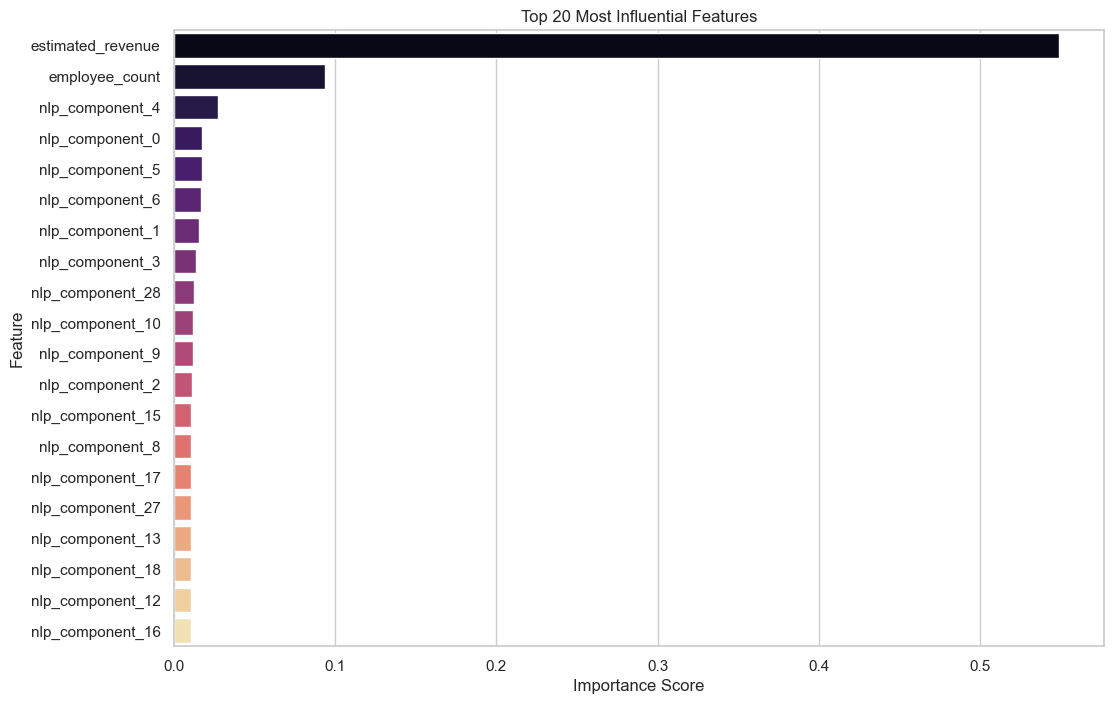

In [8]:
# 2. Feature Importance Analysis
# Extract the XGBoost model from the multi-output wrapper
xgb_model = engine.pipeline.named_steps["model"].regressor_.estimators_[0]

# Get feature names from the preprocessor
# Note: NLP features are compressed via PCA, so we name them accordingly
fin_features = engine.fin_cols
cat_features = engine.cat_cols
nlp_features = [f"nlp_component_{i}" for i in range(30)]
all_features = fin_features + cat_features + nlp_features

importances = xgb_model.feature_importances_
feat_imp_df = pd.DataFrame({"feature": all_features, "importance": importances})
feat_imp_df = feat_imp_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=feat_imp_df, x="importance", y="feature", palette="magma")
plt.title("Top 20 Most Influential Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [7]:
print(engine.fin_cols)
print(engine.cat_cols)

['employee_count', 'estimated_revenue']
['sector']
